# Iris Dataset EDA 실습

이 노트북은 붓꽃(Iris) 데이터를 이용하여 탐색적 데이터 분석(EDA, Exploratory Data Analysis)의 기본 흐름을 실습하기 위한 자료입니다. EDA의 목적은 단순히 그래프를 그리는 것이 아니라, 데이터의 구조와 품질을 확인하고 변수의 분포와 관계를 이해하여 이후 통계 분석이나 머신러닝을 위한 가설을 만드는 것입니다.

이번 실습에서는 다음 내용을 확인합니다.

1. 데이터 불러오기
2. 데이터 구조 확인
3. 결측치와 중복 데이터 확인
4. 레이블 종류와 개수 확인
5. 기술통계량 확인
6. 품종별 평균과 표준편차 확인
7. 변수별 분포 확인
8. 품종별 분포 비교
9. Box Plot과 Violin Plot
10. Pair Plot
11. 상관관계 분석
12. 산점도를 이용한 변수 관계 확인
13. IQR 기반 이상치 탐지
14. 품종별 평균 비교
15. 변동계수 확인
16. 변수별 품종 분리도 확인


In [1]:
# Google Colab에서 Google Drive를 사용할 때만 마운트합니다.
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ModuleNotFoundError:
    print('로컬 환경에서는 Google Drive 마운트를 건너뜁니다.')


로컬 환경에서는 Google Drive 마운트를 건너뜁니다.


## 1. 필요한 라이브러리 불러오기

`pandas`는 데이터 처리, `numpy`는 수치 계산, `matplotlib`과 `seaborn`은 시각화를 위해 사용합니다.

Google Colab에서는 CSV 파일을 직접 업로드할 수 있습니다.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")

## 2. 데이터 불러오기

아래 셀을 실행하면 파일 선택 창이 나타납니다.

`iris (1).csv` 파일을 선택하면 CSV 파일을 읽어 `df`라는 DataFrame에 저장합니다.


In [3]:
from pathlib import Path

# Colab에서는 업로드한 파일 또는 Google Drive의 파일을 사용할 수 있습니다.
candidate_paths = [
    Path('/content/drive/MyDrive/Colab Notebooks/iris.csv'),
    Path('iris.csv'),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError('iris.csv 파일을 현재 폴더 또는 Google Drive 경로에 넣어 주세요.')

df = pd.read_csv(data_path)
print(f'불러온 파일: {data_path}')
df


불러온 파일: iris.csv


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## 3. 데이터 구조 확인

EDA의 첫 단계는 데이터가 몇 개의 행과 열로 구성되어 있는지, 어떤 변수들이 존재하는지 확인하는 것입니다.

- `shape`: 행과 열의 개수
- `head()`: 처음 5개 행
- `columns`: 변수 이름
- `dtypes`: 각 변수의 자료형
- `info()`: 데이터 전체 구조 요약


In [4]:
print("데이터 크기:", df.shape)

print("\n처음 5개 데이터")
display(df.head())

print("\n변수 이름")
print(df.columns.tolist())

print("\n자료형")
print(df.dtypes)

print("\n데이터 정보")
df.info()

데이터 크기: (150, 5)

처음 5개 데이터


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa



변수 이름
['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'species']

자료형
sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species                str
dtype: object

데이터 정보
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sepal_length_cm  150 non-null    float64
 1   sepal_width_cm   150 non-null    float64
 2   petal_length_cm  150 non-null    float64
 3   petal_width_cm   150 non-null    float64
 4   species          150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 7.2 KB


## 4. 결측치와 중복 데이터 확인

결측치는 값이 비어 있는 데이터를 의미합니다. 결측치가 많으면 분석 결과에 영향을 줄 수 있으므로 반드시 확인해야 합니다.

중복 데이터는 동일한 관측값이 여러 번 존재하는 경우입니다. 중복 데이터가 많으면 특정 관측값이 분석 결과에 과도한 영향을 줄 수 있습니다.


In [5]:
print("변수별 결측치 개수")
print(df.isnull().sum())

print("\n중복 행 개수")
print(df.duplicated().sum())

변수별 결측치 개수
sepal_length_cm    0
sepal_width_cm     0
petal_length_cm    0
petal_width_cm     0
species            0
dtype: int64

중복 행 개수
1


## 5. 분석 변수 지정

붓꽃 데이터에는 네 개의 연속형 측정 변수와 하나의 품종 레이블이 있습니다.

- `sepal_length_cm`: 꽃받침 길이
- `sepal_width_cm`: 꽃받침 너비
- `petal_length_cm`: 꽃잎 길이
- `petal_width_cm`: 꽃잎 너비
- `species`: 붓꽃 품종


In [6]:
numeric_cols = [
    'sepal_length_cm',
    'sepal_width_cm',
    'petal_length_cm',
    'petal_width_cm'
]

target_col = 'species'

## 6. 레이블 종류와 개수 확인

분류 문제에서는 각 레이블이 무엇인지, 그리고 각 레이블의 데이터 개수가 얼마나 되는지 확인하는 것이 중요합니다.

레이블별 데이터 수가 크게 차이 난다면 클래스 불균형 문제가 있을 수 있습니다.


In [7]:
print("레이블 종류")
print(df[target_col].unique())

print("\n레이블별 개수")
print(df[target_col].value_counts())

레이블 종류
<ArrowStringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

레이블별 개수
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


In [8]:
# 레이블 갯수 확인 (숫자)

df['species'].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### 레이블 개수 시각화

`countplot`은 각 범주에 몇 개의 데이터가 존재하는지 막대그래프로 보여줍니다.

막대 위에 실제 데이터 개수도 함께 표시합니다.


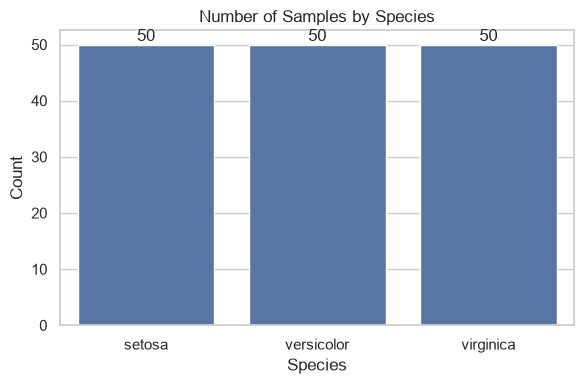

In [9]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(
    data=df,
    x=target_col
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Number of Samples by Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

## 7. 기술통계량 확인

`describe()`는 수치형 변수의 기본적인 통계량을 보여줍니다.

- `count`: 데이터 개수
- `mean`: 평균
- `std`: 표준편차
- `min`: 최솟값
- `25%`: 1사분위수
- `50%`: 중앙값
- `75%`: 3사분위수
- `max`: 최댓값

이를 통해 데이터의 전체적인 범위와 분포를 빠르게 파악할 수 있습니다.


In [10]:
display(df[numeric_cols].describe().round(3))

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


## 8. 품종별 평균과 표준편차 확인

`groupby()`를 이용하면 데이터를 품종별로 나누어 평균과 표준편차를 계산할 수 있습니다.

품종별 평균 차이가 큰 변수는 품종 구별에 유용할 가능성이 있습니다.


In [11]:
print("품종별 평균")
display(
    df.groupby(target_col)[numeric_cols]
      .mean()
      .round(3)
)

print("품종별 표준편차")
display(
    df.groupby(target_col)[numeric_cols]
      .std()
      .round(3)
)

품종별 평균


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
species,,,,
setosa,5.006,3.428,1.462,0.246
versicolor,5.936,2.770,4.260,1.326
virginica,6.588,2.974,5.552,2.026


품종별 표준편차


,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
species,,,,
setosa,0.352,0.379,0.174,0.105
versicolor,0.516,0.314,0.470,0.198
virginica,0.636,0.322,0.552,0.275


## 9. 각 변수의 전체 분포 확인

히스토그램은 값이 어느 구간에 많이 존재하는지 보여줍니다.

`kde=True`를 사용하면 데이터 분포를 부드러운 밀도 곡선으로 함께 표시할 수 있습니다.


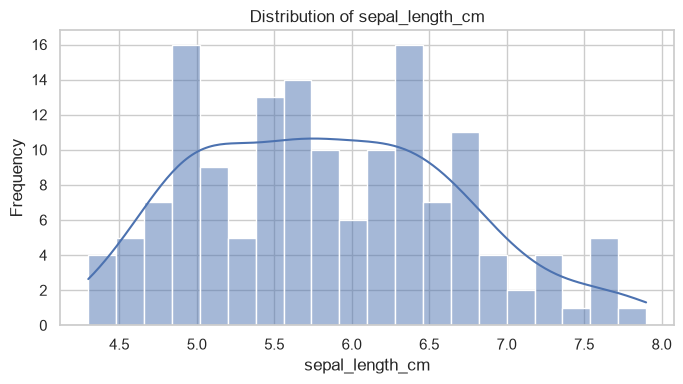

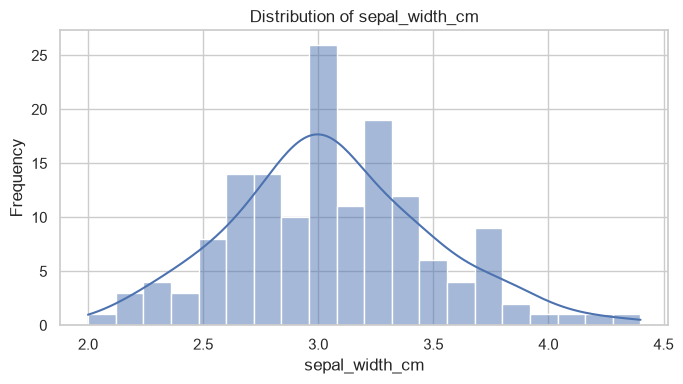

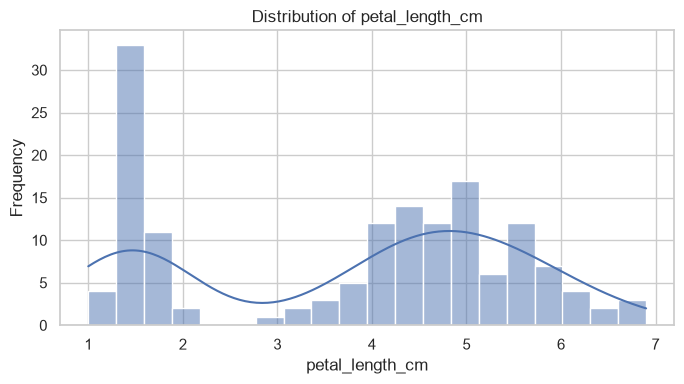

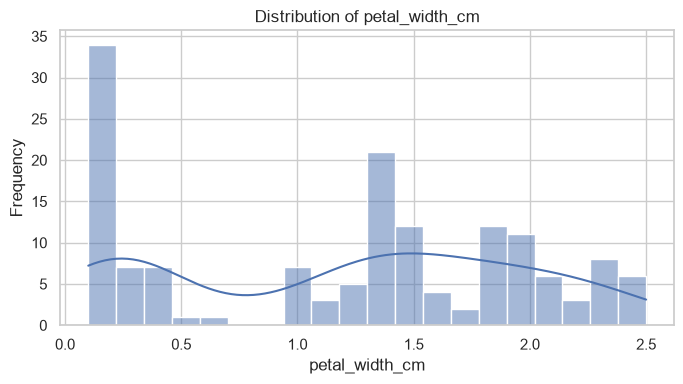

In [12]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        bins=20,
        kde=True
    )

    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

## 10. 품종별 변수 분포 비교

같은 변수에서 `setosa`, `versicolor`, `virginica`의 분포를 동시에 비교합니다.

품종별 분포가 서로 많이 떨어져 있다면 해당 변수가 품종을 구별하는 데 유용할 가능성이 높습니다.


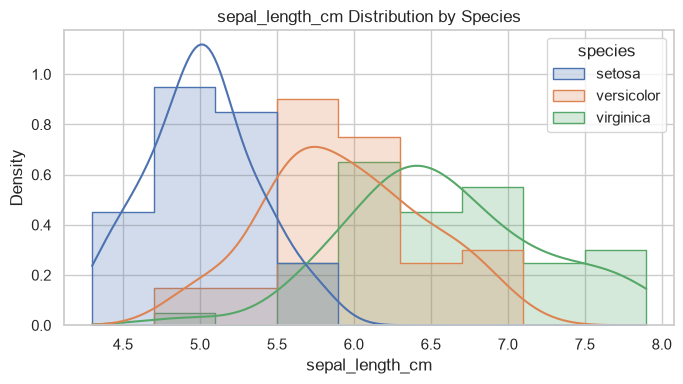

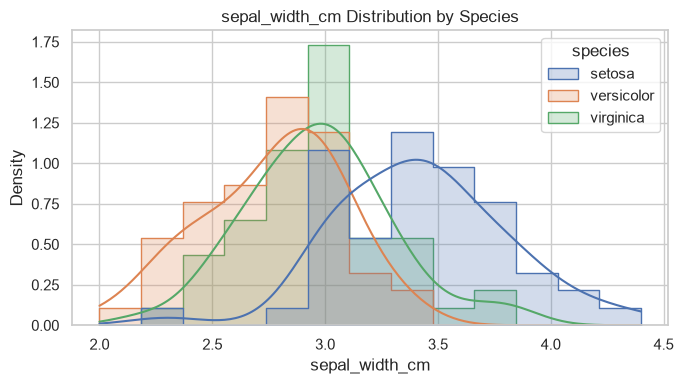

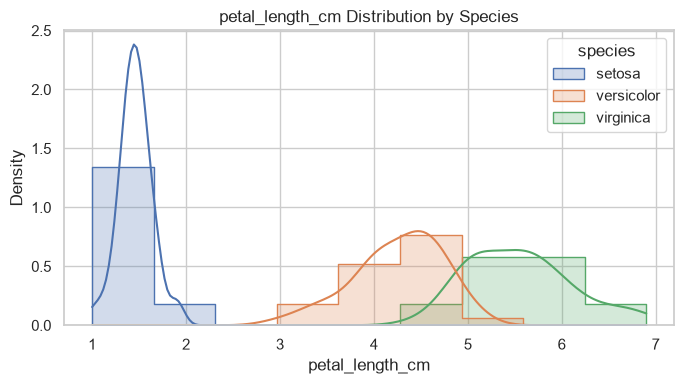

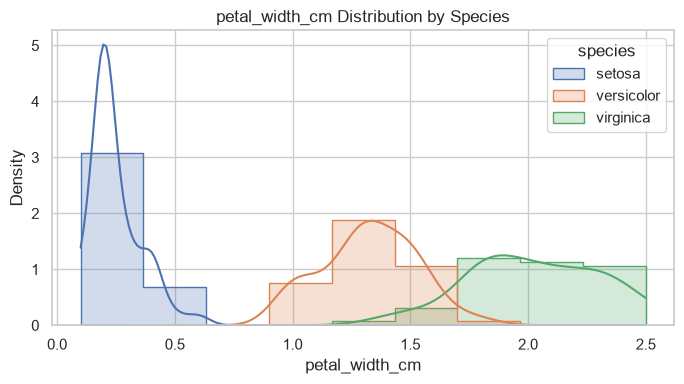

In [13]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=df,
        x=col,
        hue=target_col,
        kde=True,
        element="step",
        stat="density",
        common_norm=False
    )

    plt.title(f"{col} Distribution by Species")

    plt.tight_layout()
    plt.show()

## 11. Box Plot

Box Plot은 중앙값, 사분위수, 데이터 범위, 이상치 등을 한 번에 확인할 수 있습니다.

품종별 중앙값과 분포 범위를 비교하면 각 변수에서 품종 차이가 얼마나 큰지 확인할 수 있습니다.


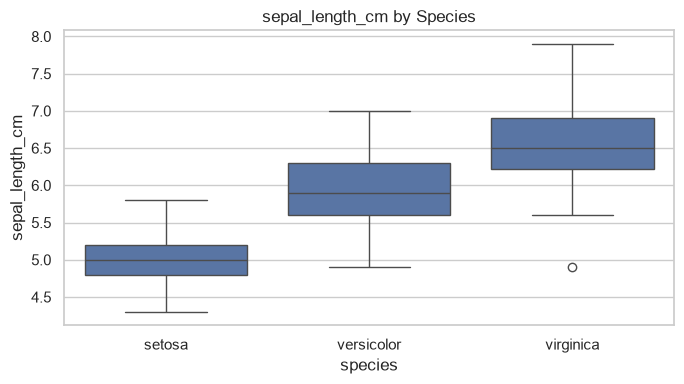

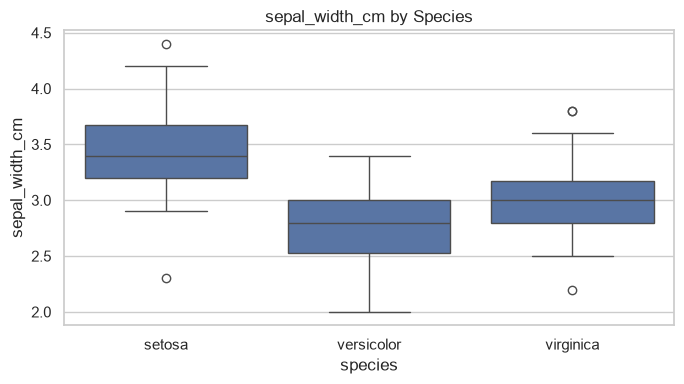

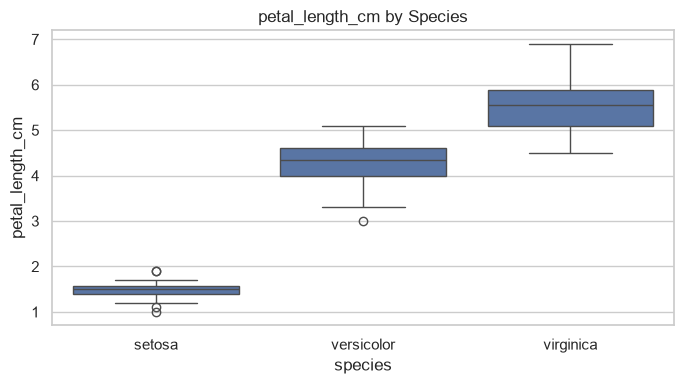

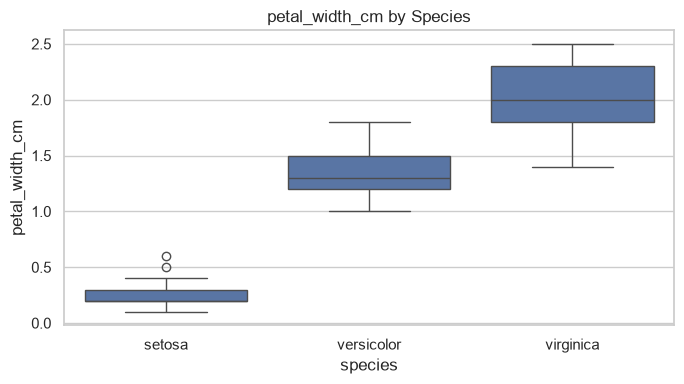

In [14]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.boxplot(
        data=df,
        x=target_col,
        y=col
    )

    plt.title(f"{col} by Species")

    plt.tight_layout()
    plt.show()

## 12. Violin Plot

Violin Plot은 Box Plot과 유사하지만 데이터의 밀도까지 함께 보여줍니다.

그래프가 넓은 부분은 해당 값 근처에 데이터가 많이 존재한다는 의미입니다.


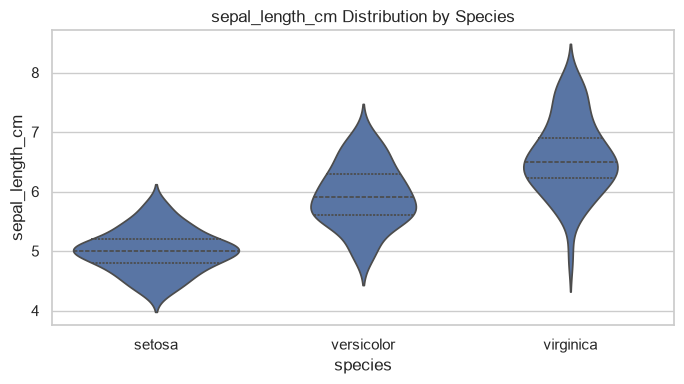

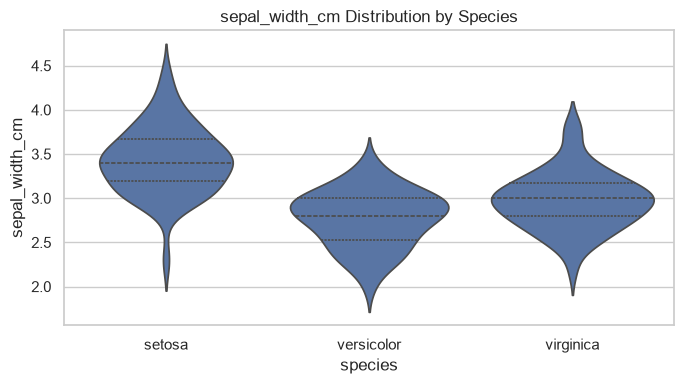

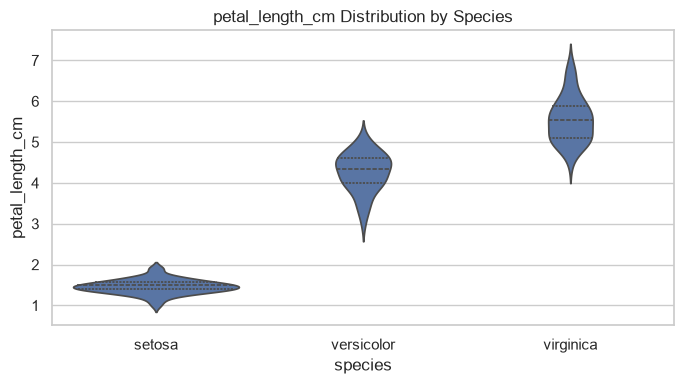

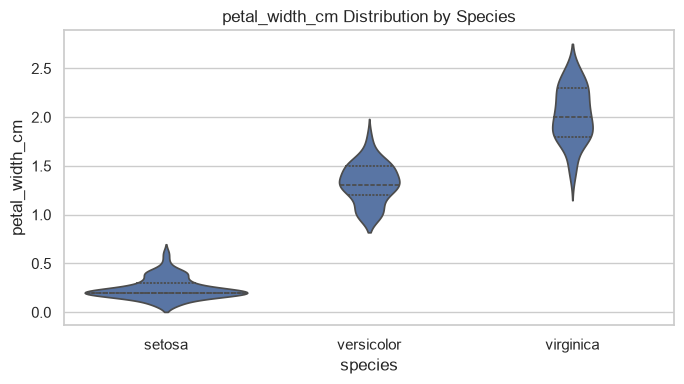

In [15]:
for col in numeric_cols:

    plt.figure(figsize=(7, 4))

    sns.violinplot(
        data=df,
        x=target_col,
        y=col,
        inner="quartile"
    )

    plt.title(f"{col} Distribution by Species")

    plt.tight_layout()
    plt.show()

## 13. Pair Plot

Pair Plot은 모든 변수 조합의 관계를 한 번에 보여주는 매우 유용한 EDA 그래프입니다.

색으로 품종을 구분하면 어떤 변수 조합에서 품종이 잘 분리되는지 직관적으로 확인할 수 있습니다.


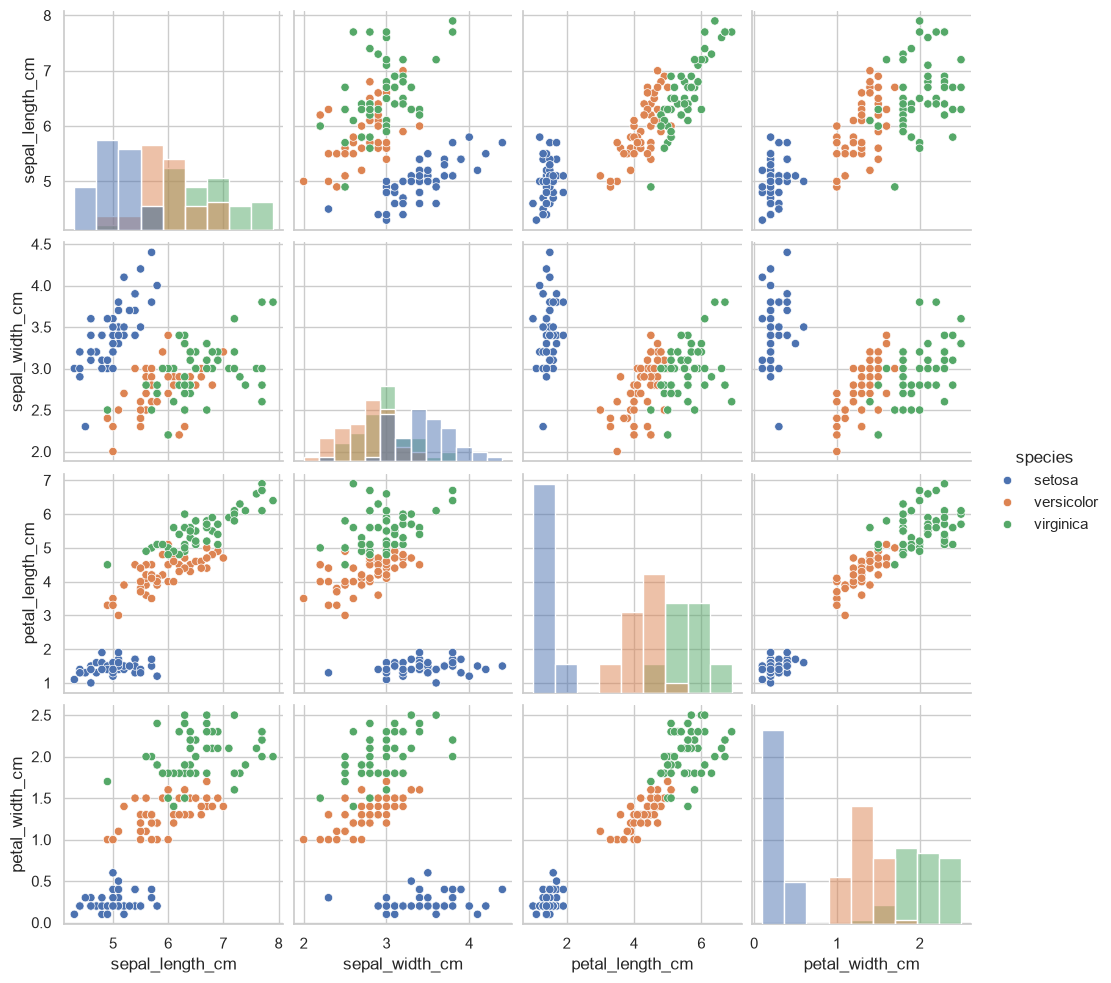

In [16]:
sns.pairplot(
    df,
    vars=numeric_cols,
    hue=target_col,
    diag_kind="hist"
)

plt.show()

## 14. 변수 간 상관관계 분석

상관계수는 두 변수 사이의 선형적인 관계를 나타냅니다.

- 1에 가까움: 강한 양의 상관관계
- 0에 가까움: 선형적인 관계가 약함
- -1에 가까움: 강한 음의 상관관계

상관관계가 높다고 해서 반드시 인과관계가 있다는 의미는 아닙니다.


In [17]:
corr = df[numeric_cols].corr()

display(corr.round(3))

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm
sepal_length_cm,1.000,-0.118,0.872,0.818
sepal_width_cm,-0.118,1.000,-0.428,-0.366
petal_length_cm,0.872,-0.428,1.000,0.963
petal_width_cm,0.818,-0.366,0.963,1.000


### 상관관계 Heatmap

Heatmap을 이용하면 변수 사이의 상관관계를 색과 숫자로 쉽게 비교할 수 있습니다.


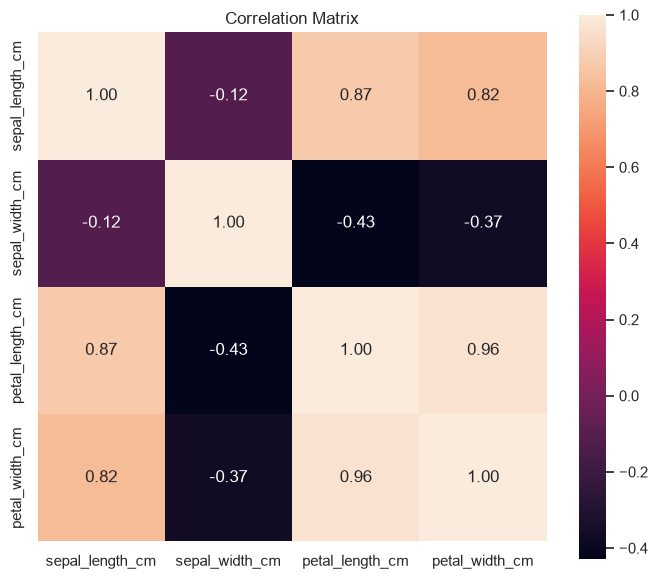

In [18]:
plt.figure(figsize=(7, 6))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    square=True
)

plt.title("Correlation Matrix")

plt.tight_layout()
plt.show()

## 15. 꽃잎 길이와 꽃잎 너비의 관계

산점도는 두 연속형 변수 사이의 관계를 확인할 때 사용합니다.

각 점은 하나의 붓꽃 샘플이며, 색은 품종을 나타냅니다.

꽃잎 길이와 꽃잎 너비는 품종별 군집이 비교적 뚜렷하게 나타나는 변수입니다.


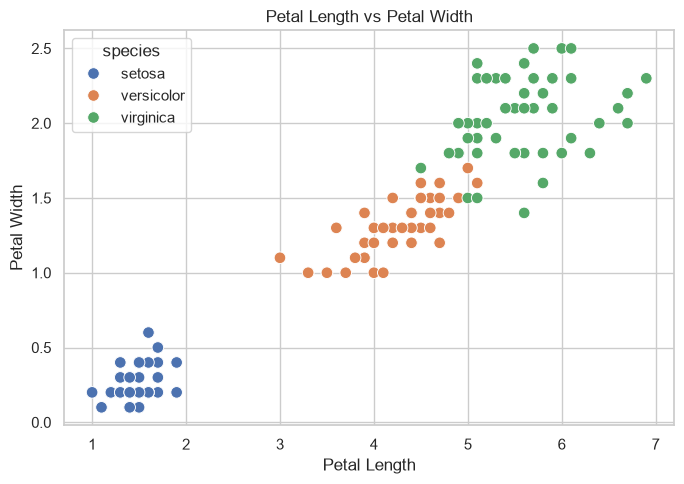

In [19]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='petal_length_cm',
    y='petal_width_cm',
    hue=target_col,
    s=70
)

plt.title("Petal Length vs Petal Width")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

plt.tight_layout()
plt.show()

## 16. 꽃받침 길이와 꽃받침 너비의 관계

꽃잎 변수와 비교하기 위해 꽃받침 길이와 너비의 관계도 확인합니다.

꽃받침 변수에서는 품종별 데이터가 상대적으로 더 많이 겹치는 것을 볼 수 있습니다.


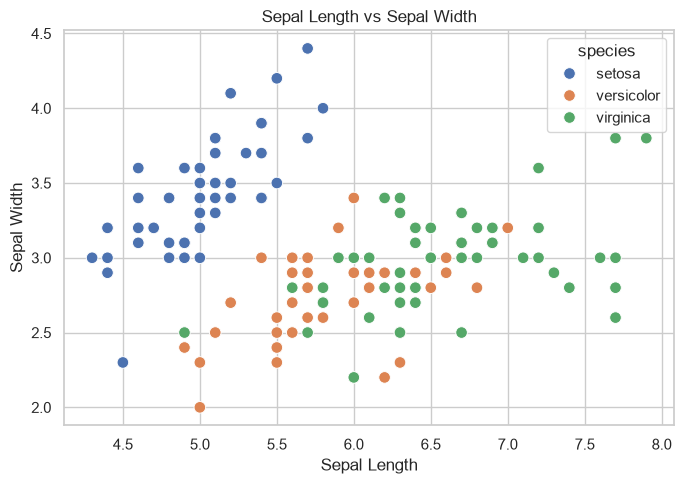

In [20]:
plt.figure(figsize=(7, 5))

sns.scatterplot(
    data=df,
    x='sepal_length_cm',
    y='sepal_width_cm',
    hue=target_col,
    s=70
)

plt.title("Sepal Length vs Sepal Width")
plt.xlabel("Sepal Length")
plt.ylabel("Sepal Width")

plt.tight_layout()
plt.show()

## 17. IQR을 이용한 이상치 탐지

IQR은 3사분위수와 1사분위수의 차이입니다.

`IQR = Q3 - Q1`

일반적으로 다음 범위를 벗어나는 값을 이상치 후보로 판단합니다.

- 하한: `Q1 - 1.5 × IQR`
- 상한: `Q3 + 1.5 × IQR`

이상치로 탐지되었다고 해서 반드시 삭제해야 하는 것은 아닙니다. 실제 오류인지 정상적인 극단값인지 추가 확인이 필요합니다.


In [21]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    print(
        f"{col:20s} : "
        f"{len(outliers)}개 "
        f"(Lower={lower:.2f}, Upper={upper:.2f})"
    )

sepal_length_cm      : 0개 (Lower=3.15, Upper=8.35)
sepal_width_cm       : 4개 (Lower=2.05, Upper=4.05)
petal_length_cm      : 0개 (Lower=-3.65, Upper=10.35)
petal_width_cm       : 0개 (Lower=-1.95, Upper=4.05)


### 실제 이상치 데이터 확인

이상치 개수뿐 아니라 어떤 데이터가 이상치 후보인지 직접 확인합니다.


In [22]:
for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower) |
        (df[col] > upper)
    ]

    if len(outliers) > 0:
        print(f"\n[{col} 이상치]")
        display(outliers[[col, target_col]])


[sepal_width_cm 이상치]


,sepal_width_cm,species
15,4.4,setosa
32,4.1,setosa
33,4.2,setosa
60,2.0,versicolor


## 18. 품종별 평균값 비교

각 품종의 평균적인 꽃받침 길이, 꽃받침 너비, 꽃잎 길이, 꽃잎 너비를 하나의 막대그래프로 비교합니다.

품종 사이의 평균 차이가 큰 변수는 분류에 유용할 가능성이 있습니다.


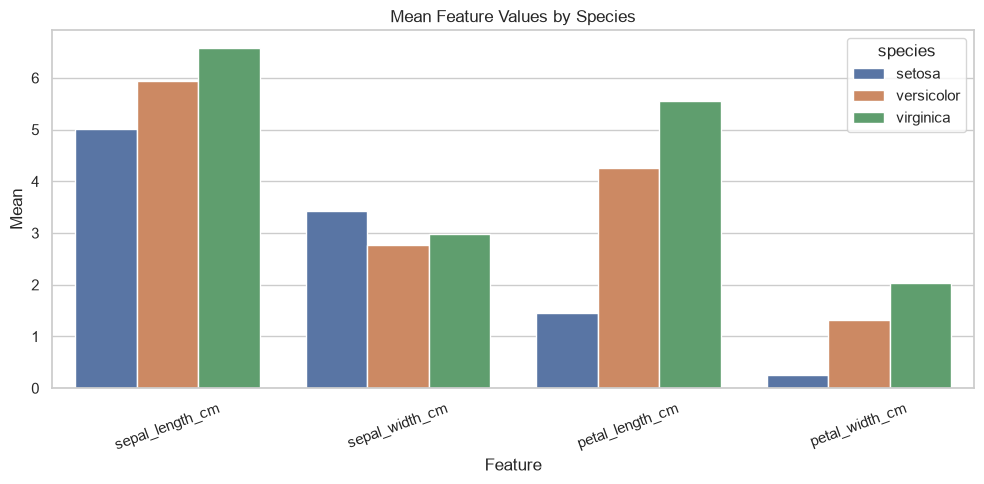

In [23]:
mean_long = (
    df.groupby(target_col)[numeric_cols]
      .mean()
      .reset_index()
      .melt(
          id_vars=target_col,
          var_name="Feature",
          value_name="Mean"
      )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=mean_long,
    x="Feature",
    y="Mean",
    hue=target_col
)

plt.title("Mean Feature Values by Species")
plt.xlabel("Feature")
plt.ylabel("Mean")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

## 21. EDA 결과를 어떻게 해석할 것인가

이 실습에서 EDA의 흐름은 다음과 같습니다.

**데이터 구조 확인 → 데이터 품질 확인 → 레이블 확인 → 기술통계 → 분포 확인 → 품종별 비교 → 변수 관계 확인 → 상관관계 → 이상치 → 중요한 변수 탐색**

붓꽃 데이터에서는 특히 꽃잎 길이(`petal_length_cm`)와 꽃잎 너비(`petal_width_cm`)가 품종에 따라 큰 차이를 보이는지 확인할 수 있습니다.

반면 꽃받침 관련 변수에서는 품종 사이의 데이터가 상대적으로 더 많이 겹칠 수 있습니다.

이와 같이 EDA를 통해 이후 머신러닝을 수행하기 전에 다음과 같은 질문을 만들 수 있습니다.

- 어떤 변수가 분류에 가장 유용할까?
- 서로 매우 강하게 상관된 변수가 있는가?
- 이상치가 모델 학습에 영향을 줄 가능성이 있는가?
- 클래스 불균형 문제가 있는가?
- 일부 변수만으로도 품종을 충분히 구별할 수 있는가?

즉, EDA는 이후 분석 방향을 결정하기 위한 데이터 이해 과정입니다.
